In [53]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk import tokenize
import os
import asyncpg
from dotenv import load_dotenv
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse
from tqdm import tqdm
import numpy as np
import pandas as pd

print(load_dotenv())


OUTPUT_DIR = './data'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2


True
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Connect to db

In [54]:
DATABASE_URL = os.getenv('DATABASE_URL')
if (DATABASE_URL is None):
    raise ValueError("DATABASE_URL is not set in environment variables")


def remove_schema_param(url):
    """Remove the schema parameter from DATABASE_URL for asyncpg"""
    parsed = urlparse(url)
    query_params = parse_qs(parsed.query)

    # Remove 'schema' parameter if it exists
    query_params.pop('schema', None)

    # Rebuild the URL without schema parameter
    new_query = urlencode(query_params, doseq=True)
    new_parsed = parsed._replace(query=new_query)
    return urlunparse(new_parsed)


## Use regular SQL
# Remove schema parameter for asyncpg
asyncpg_url = remove_schema_param(DATABASE_URL)
conn = await asyncpg.connect(dsn=asyncpg_url)
comment_count = await conn.fetchval('SELECT COUNT(*) FROM "Comment";')
print(f'Comment count with SQL: {comment_count}')



Comment count with SQL: 627111


Create Events table

In [55]:
# get column metadata for public."Event"
event_schema_q = """
SELECT a.attnum AS ordinal_position,
  a.attname AS column_name,
  format_type(a.atttypid, a.atttypmod) AS data_type,
  NOT a.attnotnull AS is_nullable,
  pg_get_expr(ad.adbin, ad.adrelid) AS column_default
FROM pg_attribute a
LEFT JOIN pg_attrdef ad ON a.attrelid = ad.adrelid AND a.attnum = ad.adnum
WHERE a.attrelid = 'public."Event"'::regclass
  AND a.attnum > 0
  AND NOT a.attisdropped
ORDER BY a.attnum;
"""
event_cols = await conn.fetch(event_schema_q)
if not event_cols:
  raise ValueError('Table public."Event" not found or has no columns')

# schema as DataFrame
event_schema = pd.DataFrame([dict(c) for c in event_cols])

# fetch all rows and convert to DataFrame
event_rows = await conn.fetch('SELECT * FROM "Event";')
event_df = pd.DataFrame([dict(r) for r in event_rows])
print(f'Loaded {len(event_df)} rows into event_df')
event_df.head()

event_df = event_df[event_df['closed'] == True]
event_df = event_df[event_df['commentCount'] > 30]
print(event_df.shape)
event_df.to_parquet(f'{OUTPUT_DIR}/events.parquet', index=False)

Loaded 65056 rows into event_df
(38382, 76)


In [56]:
event_df = pd.read_parquet(f'{OUTPUT_DIR}/events.parquet')

----

In [57]:
valid_event_ids = event_df['id'].tolist()

# convert ids to strings to form ('10016', '10017', ...)
valid_event_ids_str = "', '".join([str(eid) for eid in valid_event_ids])
valid_event_ids_str = f"('{valid_event_ids_str}')"
print(valid_event_ids_str)

('5812', '5841', '4381', '4076', '5563', '5840', '5570', '5601', '5556', '4051', '3521', '5532', '5530', '5642', '5521', '5867', '901427', '5451', '5864', '5600', '5633', '5517', '5688', '5568', '5704', '5566', '2968', '5598', '3085', '5573', '5538', '5539', '5589', '901428', '5845', '5643', '5868', '5673', '4640', '5866', '5659', '5588', '5551', '5571', '5516', '5876', '5874', '3347', '901919', '5707', '5663', '3318', '5514', '5838', '5640', '901931', '3952', '5836', '3145', '5545', '5555', '5130', '2923', '5592', '5562', '5616', '5567', '5529', '3438', '5829', '5831', '5827', '5834', '4929', '901932', '3515', '4599', '4022', '5523', '3803', '5528', '5536', '5550', '5620', '5833', '5634', '5520', '5548', '5515', '5581', '901499', '5559', '5603', '5549', '5630', '5873', '5564', '5579', '5524', '5587', '5632', '902604', '4044', '4480', '4251', '5533', '5622', '5872', '5870', '5645', '5869', '5526', '5590', '4050', '5572', '5644', '901860', '4304', '5636', '5628', '5691', '5522', '5626',

Create markets table

In [58]:

get_markets_sql = f"""
SELECT em."A" as "event_id", m.*
FROM "public"."Market" m
INNER JOIN "public"."_EventToMarket" em ON m."id" = em."B"
WHERE em."A" IN {valid_event_ids_str};
"""
markets = await conn.fetch(get_markets_sql)
market_df = pd.DataFrame([dict(m) for m in markets])

# cast outcomes and outcomePrices to lists
market_df['outcomes'] = market_df['outcomes'].apply(lambda x: eval(x))
market_df['outcomePrices'] = market_df['outcomePrices'].apply(lambda x: eval(x))
market_df = market_df[market_df['outcomes'].apply(lambda x: len(x)== 2)]
market_df['label'] = market_df['outcomePrices'].apply(lambda prices: 1 if prices[0] > prices[1] else 0)

market_df.to_parquet(f'{OUTPUT_DIR}/markets.parquet', index=False)

In [59]:
market_df = pd.read_parquet(f'{OUTPUT_DIR}/markets.parquet')

-----

In [60]:
get_valid_comments_sql = f"""
SELECT c.*
FROM "public"."Comment" c
WHERE c."parentEntityID" IN {valid_event_ids_str};
"""

comments = await conn.fetch(get_valid_comments_sql)
comment_df = pd.DataFrame([dict(c) for c in comments])
comment_df.shape

(512932, 12)

count     1888.000000
mean       271.680085
std       2106.390486
min          1.000000
25%         38.000000
50%         76.000000
75%        132.000000
max      78010.000000
dtype: float64
Event ID with max comments: 903193 (78010 comments)


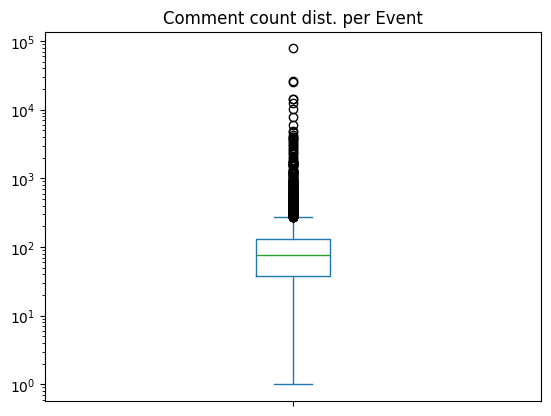

In [61]:
event_ids = comment_df['parentEntityID'].unique()

comment_count_per_event = comment_df.groupby('parentEntityID').size()
# show it on log scale
comment_count_per_event.plot(kind='box', title='Comment count dist. per Event', logy=True)
print(comment_count_per_event.describe())

# get the index with the max comments
max_comments_event_id = comment_count_per_event.idxmax()
print(f'Event ID with max comments: {max_comments_event_id} ({comment_count_per_event[max_comments_event_id]} comments)')

#add comment count per event to event_df
event_df = event_df.set_index('id')
event_df['commentCount'] = comment_count_per_event
event_df = event_df.reset_index()

In [62]:
comment_df['event_title'] = comment_df['parentEntityID'].map(event_df.set_index('id')['title'])
comment_df['event_desc'] = comment_df['parentEntityID'].map(event_df.set_index('id')['description'])
comment_df = comment_df.loc[comment_df.parentCommentID.isnull(),['id','body','parentEntityID', 'event_title', 'event_desc']]
print(comment_df.shape)

(255595, 5)


Create intermediate event-market table where each event appears once per associated market

In [63]:
# Create event-market intermediate table
# Select relevant columns from market_df and keep event_id
event_market_df = market_df[['event_id', 'id', 'outcomes', 'outcomePrices']].copy()
event_market_df.rename(columns={'id': 'market_id'}, inplace=True)

print(f"Event-Market table shape: {event_market_df.shape}")
print(f"Unique events: {event_market_df['event_id'].nunique()}")
print(f"Unique markets: {event_market_df['market_id'].nunique()}")
event_market_df.head()

Event-Market table shape: (70972, 4)
Unique events: 38381
Unique markets: 70972


,event_id,market_id,outcomes,outcomePrices
0,32008,562444,"[Up, Down]","[0, 1]"
1,32009,562445,"[Up, Down]","[1, 0]"
2,32010,562446,"[Up, Down]","[0, 1]"
3,32011,562447,"[Up, Down]","[1, 0]"
4,32012,562448,"[Up, Down]","[1, 0]"


Merge comments with event-market table (comments will be duplicated for each market under the same event)

In [64]:
# Merge comment_df with event_market_df
# Left join on parentEntityID (event_id)
comment_market_df = comment_df.merge(
    event_market_df,
    left_on='parentEntityID',
    right_on='event_id',
    how='left'
)

print(f"Original comment_df shape: {comment_df.shape}")
print(f"Final comment_market_df shape: {comment_market_df.shape}")
print(f"Unique comments: {comment_market_df['id'].nunique()}")
print(f"Unique events: {comment_market_df['event_id'].nunique()}")
print(f"Unique markets: {comment_market_df['market_id'].nunique()}")
comment_market_df.head(10)

Original comment_df shape: (255595, 5)
Final comment_market_df shape: (2199375, 9)
Unique comments: 255595
Unique events: 1888
Unique markets: 10620


,id,body,parentEntityID,event_title,event_desc,event_id,market_id,outcomes,outcomePrices
0,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]"
1,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512338,"[Yes, No]","[0, 1]"
2,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512339,"[Yes, No]","[0, 1]"
3,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512340,"[Yes, No]","[0, 1]"
4,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512341,"[Yes, No]","[0, 1]"
5,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512342,"[Yes, No]","[1, 0]"
6,860886,im sorry to dissapoint all my haters . i didnt...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]"
7,860886,im sorry to dissapoint all my haters . i didnt...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512338,"[Yes, No]","[0, 1]"
8,860886,im sorry to dissapoint all my haters . i didnt...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512339,"[Yes, No]","[0, 1]"
9,860886,im sorry to dissapoint all my haters . i didnt...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512340,"[Yes, No]","[0, 1]"


Remove duplicates where same comment + event + outcomes but different market_id (essentially markets for the same event that have the same outcomes, for these we cannot decide what a Yes or No referred to)

In [71]:
# Convert outcomes list to string for grouping (since lists are unhashable)
comment_market_df['outcomes_str'] = comment_market_df['outcomes'].apply(lambda x: str(x) if isinstance(x, list) else str(x))

print(f"Before deduplication: {comment_market_df.shape}")

# Drop duplicates keeping first occurrence
# Group by: comment id, event_id, and outcomes_str
comment_market_df_dedup = comment_market_df.drop_duplicates(
    subset=['id', 'event_id', 'outcomes_str'],
    keep='first'
).copy()

print(f"After deduplication: {comment_market_df_dedup.shape}")
print(f"Rows removed: {comment_market_df.shape[0] - comment_market_df_dedup.shape[0]}")
comment_market_df_dedup.head(10)

Before deduplication: (2199375, 10)
After deduplication: (268385, 10)
Rows removed: 1930990


,id,body,parentEntityID,event_title,event_desc,event_id,market_id,outcomes,outcomePrices,outcomes_str
0,863786,there used to be alot more activity in this ch...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
6,860886,im sorry to dissapoint all my haters . i didnt...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
12,863158,This feels like a high-stakes game,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
18,1243858,"Marx Carney is disgusting, he is even worse th...",16125,Next Prime Minister of Canada after the election?,This is a market on who will be the next Prime...,16125,516767,"[Yes, No]","[0, 1]",['Yes' 'No']
23,1243843,"Okaaaay, Singh attacks Carney on Brookfield, B...",16125,Next Prime Minister of Canada after the election?,This is a market on who will be the next Prime...,16125,516767,"[Yes, No]","[0, 1]",['Yes' 'No']
28,862839,Why do they gotta make this bets so difficult?...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
34,862427,This feels like a high-stakes game,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
40,862582,2PM will decide this game. We wait to see if C...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
46,821842,I'm ready to be the next president of Romania!,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']
52,821003,https://www.realitatea.net/stiri/actual/surse-...,14228,(Old) Romania Election,This is a market on the outcome of the upcomin...,14228,512337,"[Yes, No]","[0, 1]",['Yes' 'No']


This is necessary to further filter down to markets where the event description is detailed enough to give the LLM enough context to assess the comment.
We also remove events that start with "What will", "Which" and "When", cause these events usually do not have binary outcomes.

In [72]:
comment_market_df_dedup = comment_market_df_dedup.sort_values(by='id').reset_index(drop=True)
comment_market_df_dedup.head()

# only keep rows where event_desc contains "resolve" or "result"

comment_market_df_dedup = comment_market_df_dedup[
    comment_market_df_dedup['event_desc'].str.contains('This market will resolve to "Yes"', case=False, na=False)
].copy()

# Keep only rows where outcomes are exactly ['Yes', 'No']
comment_market_df_dedup = comment_market_df_dedup[
    comment_market_df_dedup['outcomes_str'].apply(lambda x: x == "['Yes' 'No']")
].copy()

# Drop rows where event_title starts with "What will" or "Which" as these events usually 
# give market options which are not Yes or No so it cannot be labeled correctly
comment_market_df_dedup = comment_market_df_dedup[
    ~comment_market_df_dedup['event_title'].str.startswith(("What will", "Which", "When"), na=False)
].copy()

comment_market_df_dedup.reset_index(drop=True, inplace=True)
comment_market_df_dedup.shape

(94565, 10)

In [73]:
def create_labeling_prompt(row):
    prompt = """
        <EVENT_TITLE>
        {event_title}
        </EVENT_TITLE>
        <EVENT_DESCRIPTION>
        {event_desc}
        </EVENT_DESCRIPTION>
        <COMMENT>
        {body}
        </COMMENT>

        Outcome Yes: {outcome_a}
        Outcome No: {outcome_b}

        Given the event title and description, and the comment above, does the comment indicate that Outcome Yes or Outcome No is more likely to occur?
        If you think that the comment indicates Outcome Yes is more likely, respond with "Yes".
        If you think that the comment indicates Outcome No is more likely, respond with "No".
        If the comment does not indicate either outcome, respond with "NEITHER".
    """

    outcome_a, outcome_b = row['outcomes']
    return prompt.format(
        event_title=row['event_title'],
        event_desc=row['event_desc'].strip(),
        body=row['body'],
        outcome_a=outcome_a,
        outcome_b=outcome_b
    )

comment_market_df_dedup['labeling_prompt'] = comment_market_df_dedup.apply(create_labeling_prompt, axis=1)
comment_market_df_dedup[['id', 'labeling_prompt']].head()




,id,labeling_prompt
0,1000025,\n <EVENT_TITLE>\n Will Trump cr...
1,1000042,\n <EVENT_TITLE>\n Trump declass...
2,100014,\n <EVENT_TITLE>\n Iran military...
3,1000188,\n <EVENT_TITLE>\n Google Maps r...
4,100019,\n <EVENT_TITLE>\n Iran military...


In [74]:
print(comment_market_df_dedup.loc[0,'labeling_prompt'])


        <EVENT_TITLE>
        Will Trump create Bitcoin reserve in first 100 days?
        </EVENT_TITLE>
        <EVENT_DESCRIPTION>
        This market will resolve to "Yes" if the US government holds any amount of Bitcoin in its reserves at any point between January 20, 2025, ET and  April 29, 2025, 11:59 PM ET. Otherwise, this market will resolve to "No".

Note that the US government confiscating Bitcoin does not count as holding Bitcoin reserves.

The primary resolution source for this market will be official information from the US government and/or the US federal reserve, however a consensus of credible reporting will also be used.
        </EVENT_DESCRIPTION>
        <COMMENT>
        Not gonna happen before legal framework is set up. They are only in very early stages, says David Sacks. Easy bet.
        </COMMENT>

        Outcome Yes: Yes
        Outcome No: No

        Given the event title and description, and the comment above, does the comment indicate that Outcome Yes 

In [ ]:
comment_market_df_dedup.to_parquet(f'{OUTPUT_DIR}/comments.parquet', index=False)